In [5]:
import re
import time
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_val_score,
    learning_curve
)
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    StandardScaler,
    FunctionTransformer
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.base import clone

In [6]:
test_values = pd.read_csv('/content/Test Set Values.csv')
train_labels = pd.read_csv('/content/Training Set Labels.csv')
train_values = pd.read_csv('/content/Training Set values.csv')



print("Training Set Labels Shape:", train_labels.shape)
print("Training Set Values Shape:", train_values.shape)

print("\n--- Training Set Values (First 5 rows) ---")
print(train_values.head())


print("\n--- Training Set Labels (First 5 rows) ---")
print(train_labels.head())

Training Set Labels Shape: (59400, 2)
Training Set Values Shape: (59400, 40)

--- Training Set Values (First 5 rows) ---
      id  amount_tsh date_recorded        funder  gps_height     installer  \
0  69572      6000.0    2011-03-14         Roman        1390         Roman   
1   8776         0.0    2013-03-06       Grumeti        1399       GRUMETI   
2  34310        25.0    2013-02-25  Lottery Club         686  World vision   
3  67743         0.0    2013-01-28        Unicef         263        UNICEF   
4  19728         0.0    2011-07-13   Action In A           0       Artisan   

   longitude   latitude              wpt_name  num_private  ... payment_type  \
0  34.938093  -9.856322                  none            0  ...     annually   
1  34.698766  -2.147466              Zahanati            0  ...    never pay   
2  37.460664  -3.821329           Kwa Mahundi            0  ...   per bucket   
3  38.486161 -11.155298  Zahanati Ya Nanyumbu            0  ...    never pay   
4  31.1308

In [7]:
df = pd.merge(train_values, train_labels, on='id')

print(df.head())

      id  amount_tsh date_recorded        funder  gps_height     installer  \
0  69572      6000.0    2011-03-14         Roman        1390         Roman   
1   8776         0.0    2013-03-06       Grumeti        1399       GRUMETI   
2  34310        25.0    2013-02-25  Lottery Club         686  World vision   
3  67743         0.0    2013-01-28        Unicef         263        UNICEF   
4  19728         0.0    2011-07-13   Action In A           0       Artisan   

   longitude   latitude              wpt_name  num_private  ... water_quality  \
0  34.938093  -9.856322                  none            0  ...          soft   
1  34.698766  -2.147466              Zahanati            0  ...          soft   
2  37.460664  -3.821329           Kwa Mahundi            0  ...          soft   
3  38.486161 -11.155298  Zahanati Ya Nanyumbu            0  ...          soft   
4  31.130847  -1.825359               Shuleni            0  ...          soft   

  quality_group      quantity  quantity_grou

In [8]:

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['status_group'].value_counts(normalize=True))


print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


for col in ['amount_tsh', 'gps_height', 'longitude', 'population']:
    zero_pct = (df[col] == 0).mean() * 100
    print(f"{col}: {zero_pct:.1f}% zeros")

print("\nNumeric columns:", df.select_dtypes(include='number').columns.tolist())
print("Categorical columns:", df.select_dtypes(include='object').columns.tolist())

# High cardinality check
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")

Shape: (59400, 41)

Target distribution:
status_group
functional                 0.543081
non functional             0.384242
functional needs repair    0.072677
Name: proportion, dtype: float64

Missing values:
funder                3637
installer             3655
wpt_name                 2
subvillage             371
public_meeting        3334
scheme_management     3878
scheme_name          28810
permit                3056
dtype: int64
amount_tsh: 70.1% zeros
gps_height: 34.4% zeros
longitude: 3.1% zeros
population: 36.0% zeros

Numeric columns: ['id', 'amount_tsh', 'gps_height', 'longitude', 'latitude', 'num_private', 'region_code', 'district_code', 'population', 'construction_year']
Categorical columns: ['date_recorded', 'funder', 'installer', 'wpt_name', 'basin', 'subvillage', 'region', 'lga', 'ward', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', '

Key observations from your output:

Class imbalance — functional needs repair is only 7.3%, so use stratified splits and consider weighted models later.
Useless column — recorded_by has 1 unique value. Drop it.
Redundant pairs — you have grouped versions of the same feature (e.g. extraction_type / extraction_type_group / extraction_type_class). Keep the mid-level group to avoid both high cardinality and information loss.
Ultra-high cardinality — wpt_name (37k), subvillage (19k), installer (2k), funder (1.9k), scheme_name (2.7k + 48% missing). These will hurt more than help as-is.
70% zeros in amount_tsh — too many to simply impute with median; consider a binary flag instead

# Drop useless / ultra-high-cardinality / redundant / unhelpful columns


In [9]:
drop_cols = [
    'id', 'recorded_by', 'wpt_name', 'subvillage', 'scheme_name',
    'longitude', 'latitude', 'amount_tsh',
    'extraction_type', 'extraction_type_class',
    'management_group', 'payment_type', 'quality_group',
    'quantity_group', 'source_type', 'source_class',
    'waterpoint_type_group'
]
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

print("Shape after dropping:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping: (59400, 24)
Remaining columns: ['date_recorded', 'funder', 'gps_height', 'installer', 'num_private', 'basin', 'region', 'region_code', 'district_code', 'lga', 'ward', 'population', 'public_meeting', 'scheme_management', 'permit', 'construction_year', 'extraction_type_group', 'management', 'payment', 'water_quality', 'quantity', 'source', 'waterpoint_type', 'status_group']


In [10]:

def clean_text_column(series):
    """Standardize text: lowercase, strip, remove extra spaces"""
    return (series.astype(str)
            .str.lower()
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
            .str.replace(r'[^a-z0-9 ]', '', regex=True))


df['installer_clean'] = clean_text_column(df['installer'])

installer_groups = {
    'government': ['government', 'gover', 'gove', 'go', 'govern', 'goverm',
                   'governme', 'governmen', 'central government', 'centr',
                   'central govt', 'centra govt', 'cental government',
                   'cebtral government', 'central government', 'tanzania government',
                   'tanzanian government', 'serikali', 'selikali', 'serikari'],
    'dwe': ['dwe', 'dw', 'dwe', 'dw e', 'dwe', 'dweb', 'dwe'],
    'community': ['community', 'commu', 'communit', 'comunity', 'villagers',
                  'wananchi', 'wanan', 'village council', 'villa', 'vill',
                  'villag', 'village', 'villager', 'villaers'],
    'danida': ['danida', 'danid', 'dannida', 'daniad'],
    'hesawa': ['hesawa', 'hsw', 'hesewa', 'hesawz', 'hesaw', 'hesawq', 'hesaws',
               'heesaw', 'hasawa'],
    'kkkt': ['kkkt', 'kkt', 'kkkt church', 'kkkт'],
    'rwe': ['rwe'],
    'tcrs': ['tcrs', 'tscr'],
    'world_vision': ['world vision', 'world vission', 'world visiin', 'wvt',
                     'world bank', 'would bank', 'word bank', 'wb'],
    'unicef': ['unicef', 'unisef', 'unicrf'],
    'water_aid': ['water aid', 'wateraid', 'water aidsema', 'water aidsema'],
    'district_council': ['district council', 'distri', 'district counci'],
    'lga': ['lga'],
    'tasaf': ['tasaf', 'tassaf', 'tasf'],
    'amref': ['amref', 'amrefe'],
    'norad': ['norad', 'nora', 'norad'],
    'jica': ['jica', 'jaica', 'jika', 'jeica', 'jicks'],
    'fini_water': ['fini water', 'finwater', 'finw', 'fin water', 'finn water',
                   'fini water', 'finwater'],
    'oxfam': ['oxfam', 'oxfarm'],
    'private': ['private', 'priva'],
    'dmdd': ['dmdd', 'dmmd'],
    'ces': ['ces'],
    'wedeco': ['wedeco', 'wedeko', 'wdeco'],
    'shipo': ['shipo'],
    'adra': ['adra'],
    'rc_church': ['rc church', 'rc ch', 'rc churc', 'rc c', 'roman', 'roman catholic',
                  'roman church', 'roman ca', 'roman cathoric'],
    'sema': ['sema'],
    'dwsp': ['dwsp'],
    'twesa': ['twesa'],
    'idara_ya_maji': ['idara ya maji', 'wizara ya maji'],
}

def map_to_group(value, groups):
    for group_name, keywords in groups.items():
        if value in keywords:
            return group_name
    return None

df['installer_mapped'] = df['installer_clean'].apply(
    lambda x: map_to_group(x, installer_groups)
)

top_unmapped = (df[df['installer_mapped'].isna()]['installer_clean']
                .value_counts().nlargest(10).index)
df['installer_final'] = df['installer_mapped'].fillna(
    df['installer_clean'].where(df['installer_clean'].isin(top_unmapped), 'other')
)

df['funder_clean'] = clean_text_column(df['funder'])

funder_groups = {
    'government': ['government of tanzania', 'government', 'serikali', 'serikari',
                   'selikali', 'tanzania government', 'tanzanian government'],
    'danida': ['danida', 'dannida', 'daniad', 'dagida', 'dqnida'],
    'hesawa': ['hesawa', 'hsw', 'hewasa', 'hewawa', 'hesawz', 'hesaw',
               'bahewasa', 'hhesawa', 'hesawza', 'hesawwa', 'hesswa', 'gesawa'],
    'world_bank': ['world bank', 'would bank', 'word bank', 'wb', 'world banks'],
    'rwssp': ['rwssp', 'rwsssp', 'rwsp', 'rssp', 'rwsso'],
    'kkkt': ['kkkt', 'kkkt church', 'kkt'],
    'world_vision': ['world vision', 'world visionadra', 'worldvision', 'wvt'],
    'unicef': ['unicef', 'unice', 'unicrf', 'unicet', 'uniceg', 'uniseg'],
    'tasaf': ['tasaf', 'tassaf', 'tasf', 'tassaf i', 'tassaf ii', 'tasafu',
              'tasef', 'tasae', 'taasaf', 'tasad'],
    'district_council': ['district council'],
    'dhv': ['dhv', 'dhv moro', 'dhvnorp', 'dhvswis'],
    'private': ['private individual', 'private', 'private owned', 'private person'],
    'dwsp': ['dwsp', 'dwssp'],
    'norad': ['norad', 'nora'],
    'dwe': ['dwe'],
    'netherlands': ['netherlands', 'nethalan', 'nethe', 'nerthlands', 'netherland',
                    'holland', 'holand', 'holla'],
    'jica': ['jica', 'jaica', 'jika', 'jeica'],
    'amref': ['amref', 'amrefe', 'hamref'],
    'fini_water': ['fini water', 'finwater', 'finw', 'fin water', 'finn water',
                   'fiwater'],
    'wateraid': ['wateraid', 'water aid sema', 'water aidsema', 'wate aidsema'],
    'oxfam': ['oxfam', 'oxfarm', 'oxfam gb', 'oxfarm gb'],
    'rc_church': ['rc church', 'rc ch', 'rc churc', 'rc', 'roman', 'roman catholic',
                  'roman church', 'roman ca', 'roman cathoric', 'roman cathoric same',
                  'roman cathoric church'],
    'tcrs': ['tcrs', 'tscr', 'tcrst'],
    'concern': ['concern', 'concern world wide', 'conce', 'cocen', 'cocern', 'concen'],
    'isf': ['isf'],
    'plan_international': ['plan int', 'plan international', 'plan internatio',
                           'plan tanzania'],
    'lga': ['lga'],
    'ministry_of_water': ['ministry of water', 'wizara', 'maji mugumu'],
    'water': ['water', 'wsdp'],
    'rudep': ['rudep', 'ruped'],
    'adra': ['adra'],
    'ces': ['cesgmbh', 'ces gmbh'],
    'shipo': ['shipo'],
}

df['funder_mapped'] = df['funder_clean'].apply(
    lambda x: map_to_group(x, funder_groups)
)
top_unmapped_f = (df[df['funder_mapped'].isna()]['funder_clean']
                  .value_counts().nlargest(10).index)
df['funder_final'] = df['funder_mapped'].fillna(
    df['funder_clean'].where(df['funder_clean'].isin(top_unmapped_f), 'other')
)

df['installer'] = df['installer_final']
df['funder'] = df['funder_final']
df.drop(columns=['installer_clean', 'installer_mapped', 'installer_final',
                 'funder_clean', 'funder_mapped', 'funder_final'], inplace=True)


print("Installer unique:", df['installer'].nunique())
print(df['installer'].value_counts())
print("\nFunder unique:", df['funder'].nunique())
print(df['funder'].value_counts())

Installer unique: 41
installer
dwe                           17677
other                         13543
government                     3899
nan                            3655
community                      2320
danida                         1676
hesawa                         1504
rwe                            1206
district_council               1159
world_vision                   1071
kkkt                           1012
fini_water                      783
0                               777
tcrs                            708
ces                             610
tasaf                           481
amref                           443
jica                            439
lga                             413
rc_church                       409
wedeco                          401
norad                           387
dmdd                            377
unicef                          333
oxfam                           330
idara_ya_maji                   326
twesa                           3

In [11]:
for col in ['installer', 'funder']:
    df[col] = df[col].replace({'nan': 'unknown', '0': 'unknown'})


print("Installer:")
print(df['installer'].value_counts())
print("\nFunder:")
print(df['funder'].value_counts())

Installer:
installer
dwe                           17677
other                         13543
unknown                        4432
government                     3899
community                      2320
danida                         1676
hesawa                         1504
rwe                            1206
district_council               1159
world_vision                   1071
kkkt                           1012
fini_water                      783
tcrs                            708
ces                             610
tasaf                           481
amref                           443
jica                            439
lga                             413
rc_church                       409
wedeco                          401
norad                           387
dmdd                            377
unicef                          333
oxfam                           330
idara_ya_maji                   326
twesa                           316
da                              308
wu     

In [12]:
df.drop(columns=['funder'], inplace=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (59400, 23)
Columns: ['date_recorded', 'gps_height', 'installer', 'num_private', 'basin', 'region', 'region_code', 'district_code', 'lga', 'ward', 'population', 'public_meeting', 'scheme_management', 'permit', 'construction_year', 'extraction_type_group', 'management', 'payment', 'water_quality', 'quantity', 'source', 'waterpoint_type', 'status_group']


# Pump Age

In [1]:
df['date_recorded'] = pd.to_datetime(df['date_recorded'])
df['year_recorded'] = df['date_recorded'].dt.year
df.drop(columns=['date_recorded'], inplace=True)

print("year_recorded added:", df['year_recorded'].value_counts().sort_index())

NameError: name 'pd' is not defined

In [2]:

df['construction_year'] = df['construction_year'].replace(0, np.nan)

df['pump_age'] = df['year_recorded'] - df['construction_year']

# Negative pump_age → NaN (data error)
df.loc[df['pump_age'] < 0, 'pump_age'] = np.nan

# Check all three scenarios
print("pump_age breakdown:")
print(f"  Valid values: {df['pump_age'].notna().sum()}")
print(f"  NaN (from construction_year NaN): {df['construction_year'].isna().sum()}")
print(f"  NaN (from negative age): {(df['year_recorded'] < df['construction_year']).sum()}")
print(f"  Total NaN in pump_age: {df['pump_age'].isna().sum()}")
print(f"\n{df['pump_age'].describe()}")


df.drop(columns=['construction_year', 'year_recorded'], inplace=True)

NameError: name 'df' is not defined

# Map boolean columns + remove redundant

In [15]:
df.head()

,gps_height,installer,num_private,basin,region,region_code,district_code,lga,ward,population,...,permit,extraction_type_group,management,payment,water_quality,quantity,source,waterpoint_type,status_group,pump_age
0,1390,rc_church,0,Lake Nyasa,Iringa,11,5,Ludewa,Mundindi,109,...,False,gravity,vwc,pay annually,soft,enough,spring,communal standpipe,functional,12.0
1,1399,other,0,Lake Victoria,Mara,20,2,Serengeti,Natta,280,...,True,gravity,wug,never pay,soft,insufficient,rainwater harvesting,communal standpipe,functional,3.0
2,686,world_vision,0,Pangani,Manyara,21,4,Simanjiro,Ngorika,250,...,True,gravity,vwc,pay per bucket,soft,enough,dam,communal standpipe multiple,functional,4.0
3,263,unicef,0,Ruvuma / Southern Coast,Mtwara,90,63,Nanyumbu,Nanyumbu,58,...,True,submersible,vwc,never pay,soft,dry,machine dbh,communal standpipe multiple,non functional,27.0
4,0,other,0,Lake Victoria,Kagera,18,1,Karagwe,Nyakasimbi,0,...,True,gravity,other,never pay,soft,seasonal,rainwater harvesting,communal standpipe,functional,NaN


In [16]:

df['payment_binary'] = df['payment'].apply(lambda x: 0 if x == 'never pay' else 1)

print(df['payment_binary'].value_counts())
print("\nDistribution by status:")
print(pd.crosstab(df['payment_binary'], df['status_group'], normalize='index').round(3))

payment_binary
1    34052
0    25348
Name: count, dtype: int64

Distribution by status:
status_group    functional  functional needs repair  non functional
payment_binary                                                     
0                    0.449                    0.075           0.476
1                    0.613                    0.071           0.316


In [17]:
X = df.drop(columns='status_group')
y = df['status_group']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


bool_map = {'True': 1, 'False': 0, True: 1, False: 0}
for col in ['permit', 'public_meeting']:
    X_train[col] = X_train[col].map(bool_map)
    X_val[col] = X_val[col].map(bool_map)

print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("\nRemaining NaNs:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

X_train: (47520, 22) X_val: (11880, 22)

Remaining NaNs:
public_meeting        2644
scheme_management     3129
permit                2443
pump_age             16526
dtype: int64


# pump_age: missing flag + median imputation (train median only, no leakage)

In [18]:
X_train['pump_age_missing'] = X_train['pump_age'].isna().astype(int)
X_val['pump_age_missing'] = X_val['pump_age'].isna().astype(int)

pump_age_median = X_train['pump_age'].median()

X_train['pump_age'] = X_train['pump_age'].fillna(pump_age_median)
X_val['pump_age'] = X_val['pump_age'].fillna(pump_age_median)

print(f"Median used: {pump_age_median}")
print(f"NaNs left - Train: {X_train['pump_age'].isna().sum()} | Val: {X_val['pump_age'].isna().sum()}")
print(f"\nTrain shape: {X_train.shape}")
print(f"\nRemaining NaNs in X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Median used: 13.0
NaNs left - Train: 0 | Val: 0

Train shape: (47520, 23)

Remaining NaNs in X_train:
public_meeting       2644
scheme_management    3129
permit               2443
dtype: int64


# Identify numeric vs categorical columns for pipeline routing

In [37]:
remove_cols = ['pump_age_missing', 'payment', 'district_code', 'region_code',
               'num_private', 'region', 'ward','scheme_management']


X_train = X_train.drop(columns=remove_cols, errors='ignore')
X_val = X_val.drop(columns=remove_cols, errors='ignore')


print("Remaining columns:")
print(X_train.columns.tolist())
print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

Remaining columns:
['gps_height', 'installer', 'basin', 'lga', 'population', 'public_meeting', 'permit', 'extraction_type_group', 'management', 'water_quality', 'quantity', 'source', 'waterpoint_type', 'pump_age', 'payment_binary']

X_train shape: (47520, 15)
X_val shape: (11880, 15)


In [38]:
for col in ['population', 'pump_age', 'gps_height']:
    print(f"\n=== {col} ===")
    print(X_train[col].describe())
    print(f"NaN: {X_train[col].isna().sum()}")
    print(f"Skewness: {X_train[col].skew():.2f}")
    print(f"Negative values: {(X_train[col] < 0).sum()}")


=== population ===
count    47520.000000
mean       179.805513
std        463.081564
min          0.000000
25%          0.000000
50%         25.000000
75%        215.000000
max      15300.000000
Name: population, dtype: float64
NaN: 0
Skewness: 9.33
Negative values: 0

=== pump_age ===
count    47520.000000
mean        14.532029
std         10.174176
min          0.000000
25%          8.000000
50%         13.000000
75%         16.000000
max         53.000000
Name: pump_age, dtype: float64
NaN: 0
Skewness: 1.13
Negative values: 0

=== gps_height ===
count    47520.000000
mean       669.567656
std        693.005745
min        -63.000000
25%          0.000000
50%        372.500000
75%       1320.000000
max       2770.000000
Name: gps_height, dtype: float64
NaN: 0
Skewness: 0.46
Negative values: 1202


# Preprocessors

In [39]:
numeric_cols = ['gps_height', 'population', 'public_meeting', 'permit', 'pump_age', 'payment_binary']
cat_cols = ['installer', 'basin', 'lga', 'extraction_type_group',
            'management', 'water_quality', 'quantity', 'source', 'waterpoint_type']

log_cols = ['population']
nolog_cols = ['gps_height', 'public_meeting', 'permit', 'pump_age', 'payment_binary']

linear_pre = ColumnTransformer([
    ('num_log', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(np.log1p, validate=True)),
        ('scale', StandardScaler())
    ]), log_cols),
    ('num_nolog', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), nolog_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])


tree_pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), cat_cols)
])

X_train_linear = linear_pre.fit_transform(X_train)
X_val_linear = linear_pre.transform(X_val)

X_train_tree = tree_pre.fit_transform(X_train)
X_val_tree = tree_pre.transform(X_val)

print(f"✅ Linear: {X_train_linear.shape}, {X_val_linear.shape}")
print(f"✅ Tree: {X_train_tree.shape}, {X_val_tree.shape}")
print(f"NaN in output: {np.isnan(X_train_linear).sum() + np.isnan(X_train_tree).sum()}")

✅ Linear: (47520, 234), (11880, 234)
✅ Tree: (47520, 15), (11880, 15)
NaN in output: 0


In [40]:
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_train columns: {X_train.columns.tolist()}")

X_train shape: (47520, 15)
X_val shape: (11880, 15)
X_train columns: ['gps_height', 'installer', 'basin', 'lga', 'population', 'public_meeting', 'permit', 'extraction_type_group', 'management', 'water_quality', 'quantity', 'source', 'waterpoint_type', 'pump_age', 'payment_binary']


# Train all models

In [42]:
models = {
    'Decision Tree':       ('tree', DecisionTreeClassifier(random_state=42)),
    'Random Forest':       ('tree', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    'Gradient Boosting':   ('tree', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    'AdaBoost':            ('tree', AdaBoostClassifier(n_estimators=100, random_state=42)),
    'Logistic Regression': ('linear', LogisticRegression(max_iter=1000, random_state=42)),
    'KNN':                 ('linear', KNeighborsClassifier(n_neighbors=5)),
}
total_features = X_train.shape[1]
k_values = list(range(3, total_features + 1, 2))
results = {}



for name, (prep_type, model) in models.items():
    base_pre = tree_pre if prep_type == 'tree' else linear_pre
    for k in k_values:
        pipe = Pipeline([
            ('preprocess', clone(base_pre)),
            ('feature_select', SelectKBest(mutual_info_classif, k=min(k, total_features))),
            ('model', clone(model))
        ])
        start = time.time()
        pipe.fit(X_train, y_train)
        t = time.time() - start
        acc = accuracy_score(y_val, pipe.predict(X_val))
        label = f"{name} (k={k})"
        results[label] = {'accuracy': acc, 'time': t, 'pipe': pipe}
        print(f"{label:40s} | Acc: {acc:.4f} | {t:.1f}s")
    print("-" * 65)

best = max(results, key=lambda x: results[x]['accuracy'])
print(f"\nBest: {best} → {results[best]['accuracy']:.4f}")


Decision Tree (k=3)                      | Acc: 0.7438 | 3.1s
Decision Tree (k=5)                      | Acc: 0.7594 | 3.4s
Decision Tree (k=7)                      | Acc: 0.7714 | 3.6s
Decision Tree (k=9)                      | Acc: 0.7774 | 3.3s
Decision Tree (k=11)                     | Acc: 0.7546 | 3.3s
Decision Tree (k=13)                     | Acc: 0.7528 | 4.0s
Decision Tree (k=15)                     | Acc: 0.7494 | 3.4s
-----------------------------------------------------------------
Random Forest (k=3)                      | Acc: 0.7439 | 6.7s
Random Forest (k=5)                      | Acc: 0.7606 | 7.0s
Random Forest (k=7)                      | Acc: 0.7788 | 8.2s
Random Forest (k=9)                      | Acc: 0.7759 | 10.7s
Random Forest (k=11)                     | Acc: 0.7811 | 11.9s
Random Forest (k=13)                     | Acc: 0.7854 | 11.8s
Random Forest (k=15)                     | Acc: 0.7877 | 12.2s
--------------------------------------------------------------

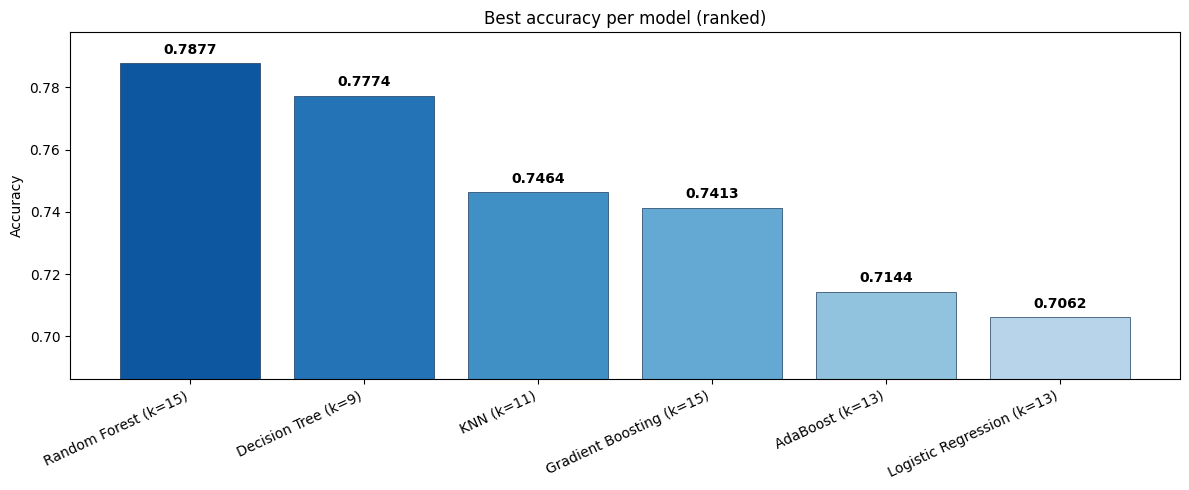

In [43]:
model_names = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'AdaBoost', 'Logistic Regression', 'KNN']
best_acc = {}
for name in model_names:
    accs = {k: v['accuracy'] for k, v in results.items() if k.startswith(name)}
    best_key = max(accs, key=accs.get)
    best_acc[best_key] = accs[best_key]


sorted_items = sorted(best_acc.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]


n = len(values)
colors = [plt.cm.Blues(0.85 - i * (0.55 / (n - 1))) for i in range(n)]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='#1a3a5c', linewidth=0.5)
ax.set_ylabel('Accuracy')
ax.set_title('Best accuracy per model (ranked)')
ax.set_ylim(min(values) - 0.02, max(values) + 0.01)
plt.xticks(rotation=25, ha='right')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [44]:
X_train.shape

(47520, 15)

In [45]:

best_pipe = results[best]['pipe']
print(f"Best model: {best}")
print(f"Pipeline steps: {best_pipe.named_steps.keys()}")


feature_selector = best_pipe.named_steps['feature_select']
print(f"SelectKBest k value: {feature_selector.k}")
print(f"Selected features: {feature_selector.get_support().sum()}")


try:
    y_pred = best_pipe.predict(X_val)
    print("Prediction successful!")
except Exception as e:
    print(f"Error: {e}")

Best model: Random Forest (k=15)
Pipeline steps: dict_keys(['preprocess', 'feature_select', 'model'])
SelectKBest k value: 15
Selected features: 15
Prediction successful!


In [46]:
y_pred = best_pipe.predict(X_val)
print(classification_report(y_val, y_pred))

                         precision    recall  f1-score   support

             functional       0.79      0.88      0.83      6452
functional needs repair       0.49      0.29      0.36       863
         non functional       0.82      0.75      0.79      4565

               accuracy                           0.79     11880
              macro avg       0.70      0.64      0.66     11880
           weighted avg       0.78      0.79      0.78     11880



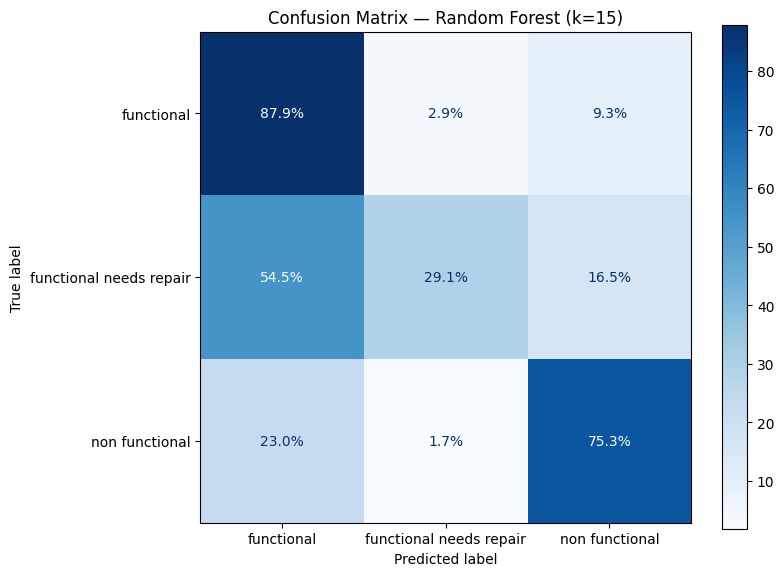

In [51]:
y_pred = best_pipe.predict(X_val)

cm = confusion_matrix(y_val, y_pred, normalize='true') * 100

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipe.classes_)
disp.plot(cmap='Blues', ax=ax, colorbar=True, values_format='.1f')

# add % symbol to each cell
for text in disp.text_.ravel():
    text.set_text(text.get_text() + '%')

ax.set_title(f'Confusion Matrix — {best}')
plt.tight_layout()
plt.show()

#Important features

In [47]:
best_key = best  # already holds the best model name from your loop
best_pipe = results[best_key]['pipe']
selector = best_pipe.named_steps['feature_select']
all_features = numeric_cols + cat_cols

print(f"Best model: {best_key}\nFeature scores:\n")
for f, score in sorted(zip(all_features, selector.scores_), key=lambda x: -x[1]):
    bar = "█" * int(score * 2)
    print(f"  {f:25s} {score:.4f}  {bar}")

Best model: Random Forest (k=15)
Feature scores:

  quantity                  0.1030  
  lga                       0.0919  
  waterpoint_type           0.0683  
  extraction_type_group     0.0586  
  installer                 0.0385  
  pump_age                  0.0347  
  source                    0.0235  
  payment_binary            0.0210  
  water_quality             0.0201  
  gps_height                0.0192  
  management                0.0177  
  population                0.0151  
  basin                     0.0142  
  public_meeting            0.0058  
  permit                    0.0042  


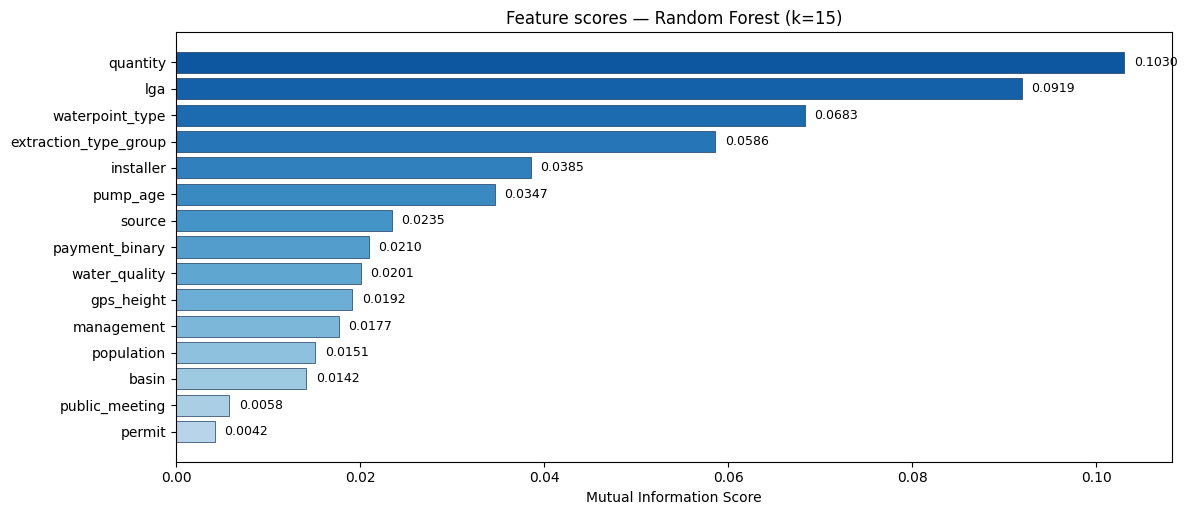

In [48]:
best_pipe = results[best]['pipe']
selector = best_pipe.named_steps['feature_select']
all_features = numeric_cols + cat_cols


feat_scores = sorted(zip(all_features, selector.scores_), key=lambda x: -x[1])
labels = [f for f, s in feat_scores]
scores = [s for f, s in feat_scores]

n = len(scores)
colors = [plt.cm.Blues(0.85 - i * (0.55 / (n - 1))) for i in range(n)]

fig, ax = plt.subplots(figsize=(12, max(5, n * 0.35)))
bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1], edgecolor='#1a3a5c', linewidth=0.5)
ax.set_xlabel('Mutual Information Score')
ax.set_title(f'Feature scores — {best}')

for bar, val in zip(bars, scores[::-1]):
    ax.text(bar.get_width() + max(scores) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [49]:
X_train.head()

,gps_height,installer,basin,lga,population,public_meeting,permit,extraction_type_group,management,water_quality,quantity,source,waterpoint_type,pump_age,payment_binary
43360,0,unknown,Lake Nyasa,Rungwe,0,1.0,NaN,gravity,vwc,soft,insufficient,spring,communal standpipe,13.0,0
7263,2049,acra,Rufiji,Njombe,175,1.0,1.0,gravity,wua,soft,enough,spring,communal standpipe,3.0,1
2486,290,other,Wami / Ruvu,Bagamoyo,2300,1.0,0.0,india mark ii,vwc,salty,insufficient,shallow well,hand pump,1.0,1
313,0,dwe,Lake Victoria,Karagwe,0,1.0,1.0,other,vwc,soft,enough,shallow well,other,13.0,0
52726,0,government,Internal,Bahi,0,1.0,1.0,mono,vwc,soft,enough,machine dbh,communal standpipe,13.0,1


In [52]:
pipe_rf = Pipeline([
     ('preprocess', clone(tree_pre)),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_dist = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [20, 30, 40, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
}

search = RandomizedSearchCV(
    pipe_rf,
    param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"\nBest CV Score: {search.best_score_:.4f}")
print(f"Best Params: {search.best_params_}")
print(f"Val Accuracy: {accuracy_score(y_val, search.predict(X_val)):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best CV Score: 0.7962
Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}
Val Accuracy: 0.7988


In [53]:
best_rf_tuned = search.best_estimator_

joblib.dump(best_rf_tuned, 'best_rf_tuned_pipeline.pkl')

print(f"Model saved: best_rf_tuned_pipeline.pkl")
print(f"  Val Accuracy: {accuracy_score(y_val, best_rf_tuned.predict(X_val)):.4f}")

Model saved: best_rf_tuned_pipeline.pkl
  Val Accuracy: 0.7988


#CONFUSION MATRIX

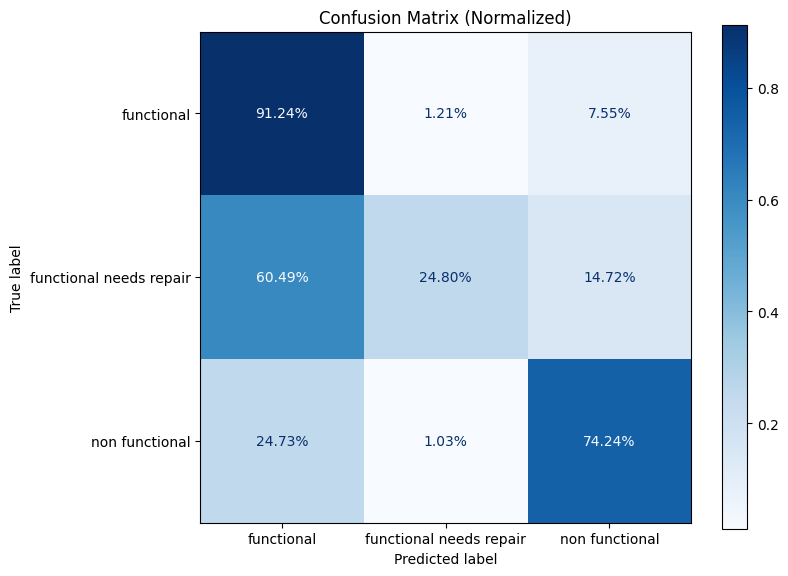

In [54]:
best_pipe = search.best_estimator_
y_pred = best_pipe.predict(X_val)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax, cmap='Blues',
                                         normalize='true', values_format='.2%')
ax.set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.show()

# OVERFITTING CHECK

In [55]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_val)
train_acc = accuracy_score(y_train, best_model.predict(X_train))
val_acc = accuracy_score(y_val, y_pred)
cv_score = search.best_score_

print("=" * 50)
print("OVERFITTING CHECK")
print("=" * 50)
print(f"  Train Accuracy:  {train_acc:.4f}")
print(f"  CV Accuracy:     {cv_score:.4f}")
print(f"  Val Accuracy:    {val_acc:.4f}")
print(f"  Train-Val Gap:   {train_acc - val_acc:.4f}")
print(f"  CV-Val Gap:      {abs(cv_score - val_acc):.4f}")

if train_acc - val_acc > 0.10:
    print("\n  ⚠️ OVERFITTING — large gap, needs regularization")
elif train_acc - val_acc > 0.05:
    print("\n  ⚠️ SLIGHT OVERFITTING — acceptable but monitor")
else:
    print("\n  ✅ GOOD — no significant overfitting")

OVERFITTING CHECK
  Train Accuracy:  0.8789
  CV Accuracy:     0.7962
  Val Accuracy:    0.7988
  Train-Val Gap:   0.0800
  CV-Val Gap:      0.0027

  ⚠️ SLIGHT OVERFITTING — acceptable but monitor


# PER-CLASS ANALYSIS

In [56]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_val, y_pred))

print("\nMISCLASSIFICATION BREAKDOWN:")
for true_class in ['functional', 'non functional', 'functional needs repair']:
    mask = y_val == true_class
    preds = pd.Series(y_pred[mask]).value_counts(normalize=True)
    total = mask.sum()
    print(f"\n  When TRUE = '{true_class}' ({total} samples):")
    for pred_class, pct in preds.items():
        label = "✓" if pred_class == true_class else "✗"
        print(f"    {label} Predicted '{pred_class}': {pct:.1%}")

CLASSIFICATION REPORT
                         precision    recall  f1-score   support

             functional       0.78      0.91      0.84      6452
functional needs repair       0.63      0.25      0.36       863
         non functional       0.85      0.74      0.79      4565

               accuracy                           0.80     11880
              macro avg       0.75      0.63      0.66     11880
           weighted avg       0.80      0.80      0.79     11880


MISCLASSIFICATION BREAKDOWN:

  When TRUE = 'functional' (6452 samples):
    ✓ Predicted 'functional': 91.2%
    ✗ Predicted 'non functional': 7.5%
    ✗ Predicted 'functional needs repair': 1.2%

  When TRUE = 'non functional' (4565 samples):
    ✓ Predicted 'non functional': 74.2%
    ✗ Predicted 'functional': 24.7%
    ✗ Predicted 'functional needs repair': 1.0%

  When TRUE = 'functional needs repair' (863 samples):
    ✗ Predicted 'functional': 60.5%
    ✓ Predicted 'functional needs repair': 24.8%
    ✗ Pred

# LEARNING CURVE

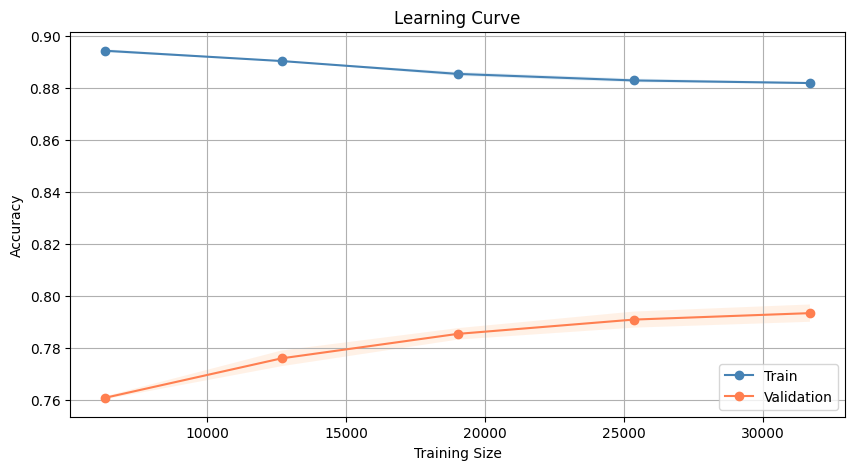

Curves converging → more data won't help much
Large gap → overfitting, try regularization
Val still rising → more data could help


In [57]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=3,
    train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
    scoring='accuracy', n_jobs=-1
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train', color='steelblue')
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation', color='coral')
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

print("Curves converging → more data won't help much")
print("Large gap → overfitting, try regularization")
print("Val still rising → more data could help")

In [60]:

pipe_regularized = Pipeline([
    ('preprocess', clone(tree_pre)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_regularized.fit(X_train, y_train)

train_acc = accuracy_score(y_train, pipe_regularized.predict(X_train))
val_acc = accuracy_score(y_val, pipe_regularized.predict(X_val))

print(f"Train: {train_acc:.4f}")
print(f"Val:   {val_acc:.4f}")
print(f"Gap:   {train_acc - val_acc:.4f}")

Train: 0.7936
Val:   0.7710
Gap:   0.0225


In [61]:
s
configs = {
    'Too complex (before)':  {'max_depth': 30, 'min_samples_split': 5,  'min_samples_leaf': 1},
    'Too simple (now)':      {'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 10},
    'Sweet spot A':          {'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4},
    'Sweet spot B':          {'max_depth': 25, 'min_samples_split': 8,  'min_samples_leaf': 3},
    'Sweet spot C':          {'max_depth': 22, 'min_samples_split': 12, 'min_samples_leaf': 5},
}

print(f"{'Config':<25} {'Train':>8} {'Val':>8} {'Gap':>8}")
print("-" * 55)

for name, params in configs.items():
    pipe = Pipeline([
        ('preprocess', clone(tree_pre)),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1,
            **params
        ))
    ])
    pipe.fit(X_train, y_train)

    tr = accuracy_score(y_train, pipe.predict(X_train))
    va = accuracy_score(y_val, pipe.predict(X_val))

    print(f"{name:<25} {tr:>8.4f} {va:>8.4f} {tr-va:>8.4f}")

Config                       Train      Val      Gap
-------------------------------------------------------
Too complex (before)        0.9102   0.7943   0.1159
Too simple (now)            0.7936   0.7710   0.0225
Sweet spot A                0.8336   0.7902   0.0433
Sweet spot B                0.8502   0.7954   0.0548
Sweet spot C                0.8290   0.7902   0.0388


In [ ]:
joblib.dump(pipe, 'best_rf_regularized_pipeline.pkl')
print(f"Saved: {best_name} → Val Acc: {best_val:.4f}, Gap: {tr-va:.4f}")

Val Accuracy: 0.7566

                         precision    recall  f1-score   support

             functional       0.82      0.78      0.80      6452
functional needs repair       0.31      0.61      0.41       863
         non functional       0.84      0.75      0.79      4565

               accuracy                           0.76     11880
              macro avg       0.66      0.71      0.67     11880
           weighted avg       0.79      0.76      0.77     11880



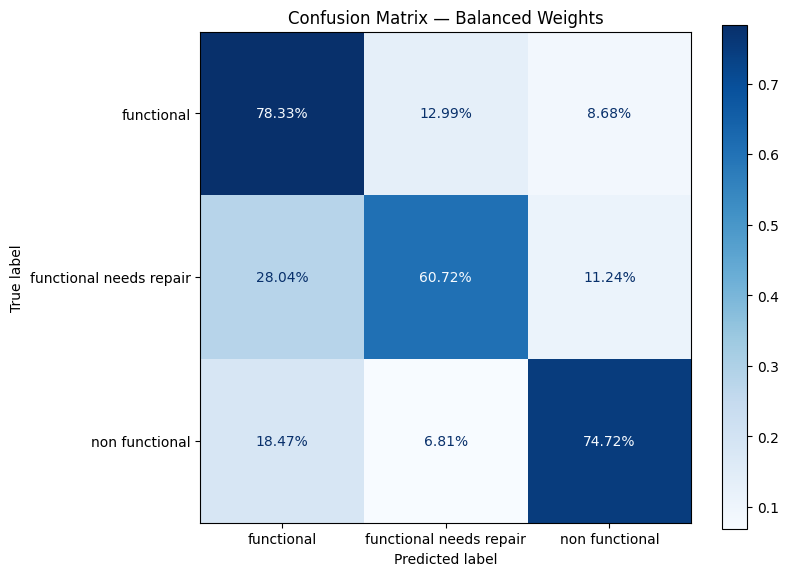

In [64]:
pipe_best = Pipeline([
    ('preprocess', clone(tree_pre)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        min_samples_split=8,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_best.fit(X_train, y_train)
y_pred = pipe_best.predict(X_val)

print(f"Val Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"\n{classification_report(y_val, y_pred)}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax, cmap='Blues',
                                         normalize='true', values_format='.2%')
ax.set_title('Confusion Matrix — Balanced Weights')
plt.tight_layout()
plt.show()

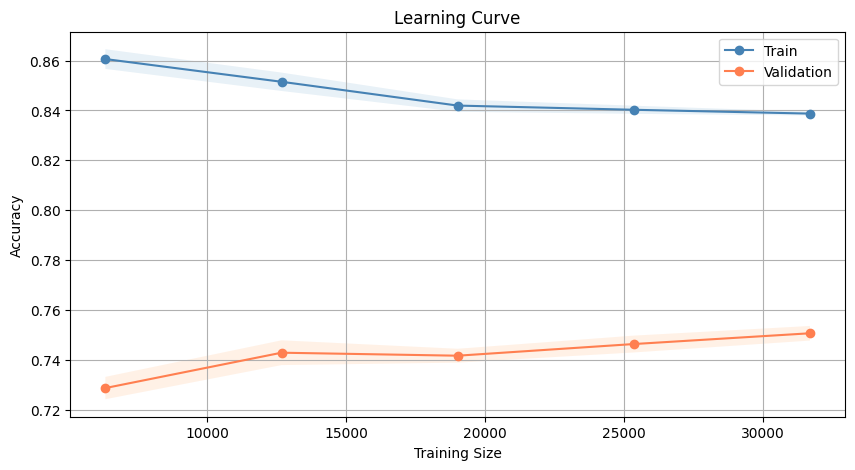

In [65]:
train_sizes, train_scores, val_scores = learning_curve(
    pipe_best, X_train, y_train, cv=3,
    train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
    scoring='accuracy', n_jobs=-1
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train', color='steelblue')
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation', color='coral')
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()



In [66]:
print(X_train.columns.tolist())
print(f"\nShape: {X_train.shape}")

['gps_height', 'installer', 'basin', 'lga', 'population', 'public_meeting', 'permit', 'extraction_type_group', 'management', 'water_quality', 'quantity', 'source', 'waterpoint_type', 'pump_age', 'payment_binary']

Shape: (47520, 15)


In [67]:
for data in [X_train, X_val]:
    data['population_zero'] = (data['population'] == 0).astype(int)
    data['log_population'] = np.log1p(data['population'])

    data['pump_age_bin'] = pd.cut(data['pump_age'],
                                  bins=[0, 5, 15, 30, 100],
                                  labels=['new', 'mid', 'old', 'very_old'])

    data['gps_height_zero'] = (data['gps_height'] == 0).astype(int)
    data['is_dry'] = (data['quantity'] == 'dry').astype(int)


installer_freq = X_train['installer'].value_counts()
lga_freq = X_train['lga'].value_counts()

for data in [X_train, X_val]:
    data['installer_freq'] = data['installer'].map(installer_freq).fillna(0)
    data['lga_freq'] = data['lga'].map(lga_freq).fillna(0)

print(f"Features now: {X_train.shape[1]}")

Features now: 22


In [68]:

numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

print(f"Numeric: {len(numeric_cols)} → {numeric_cols}")
print(f"Categorical: {len(cat_cols)} → {cat_cols}")


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

tree_pre_new = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])


pipe_new = Pipeline([
    ('preprocess', tree_pre_new),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        min_samples_split=8,
        min_samples_leaf=3,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_new.fit(X_train, y_train)
y_pred = pipe_new.predict(X_val)

print(f"\nVal Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"\n{classification_report(y_val, y_pred)}")

Numeric: 12 → ['gps_height', 'population', 'public_meeting', 'permit', 'pump_age', 'payment_binary', 'population_zero', 'log_population', 'gps_height_zero', 'is_dry', 'installer_freq', 'lga_freq']
Categorical: 10 → ['installer', 'basin', 'lga', 'extraction_type_group', 'management', 'water_quality', 'quantity', 'source', 'waterpoint_type', 'pump_age_bin']

Val Accuracy: 0.7892

                         precision    recall  f1-score   support

             functional       0.75      0.94      0.84      6452
functional needs repair       0.67      0.15      0.25       863
         non functional       0.87      0.70      0.78      4565

               accuracy                           0.79     11880
              macro avg       0.77      0.60      0.62     11880
           weighted avg       0.79      0.79      0.77     11880



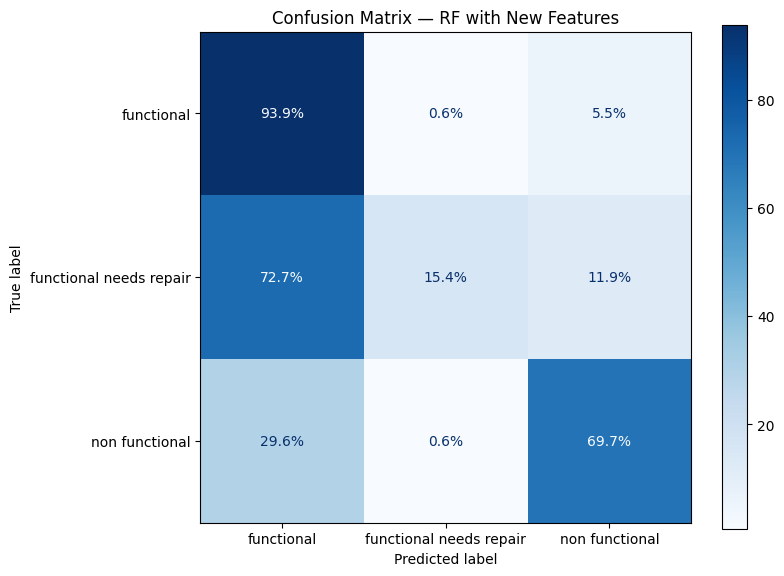

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred, normalize='true') * 100

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe_new.classes_)
disp.plot(cmap='Blues', ax=ax, colorbar=True, values_format='.1f')

for text in disp.text_.ravel():
    text.set_text(text.get_text() + '%')

ax.set_title('Confusion Matrix — RF with New Features')
plt.tight_layout()
plt.show()

In [70]:
pipe_balanced = Pipeline([
    ('preprocess', clone(tree_pre_new)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        min_samples_split=8,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_balanced.fit(X_train, y_train)
y_pred_bal = pipe_balanced.predict(X_val)

print(f"Val Accuracy: {accuracy_score(y_val, y_pred_bal):.4f}")
print(f"\n{classification_report(y_val, y_pred_bal)}")

Val Accuracy: 0.7397

                         precision    recall  f1-score   support

             functional       0.82      0.76      0.79      6452
functional needs repair       0.28      0.66      0.40       863
         non functional       0.85      0.72      0.78      4565

               accuracy                           0.74     11880
              macro avg       0.65      0.72      0.66     11880
           weighted avg       0.79      0.74      0.76     11880



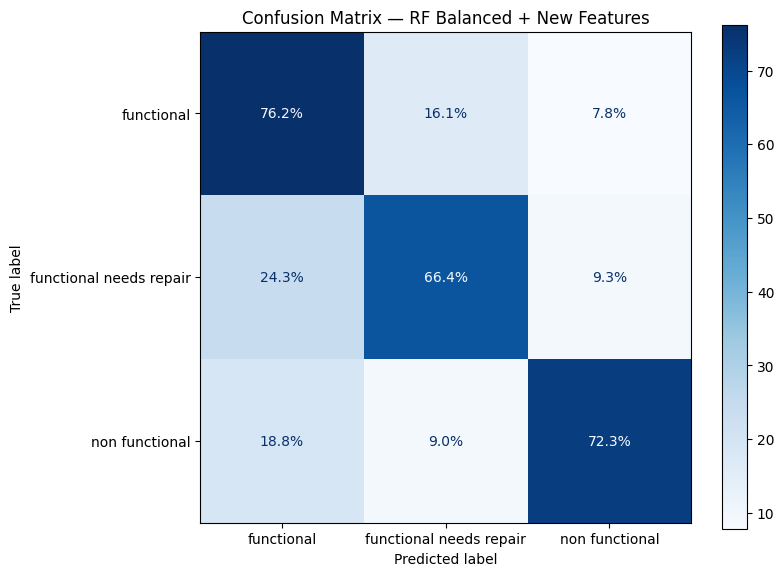


Numeric (12): ['gps_height', 'population', 'public_meeting', 'permit', 'pump_age', 'payment_binary', 'population_zero', 'log_population', 'gps_height_zero', 'is_dry', 'installer_freq', 'lga_freq']

Categorical (10): ['installer', 'basin', 'lga', 'extraction_type_group', 'management', 'water_quality', 'quantity', 'source', 'waterpoint_type', 'pump_age_bin']

Total features: 22


In [71]:

cm = confusion_matrix(y_val, y_pred_bal, normalize='true') * 100

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe_balanced.classes_)
disp.plot(cmap='Blues', ax=ax, colorbar=True, values_format='.1f')

for text in disp.text_.ravel():
    text.set_text(text.get_text() + '%')

ax.set_title('Confusion Matrix — RF Balanced + New Features')
plt.tight_layout()
plt.show()


print(f"\nNumeric ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical ({len(cat_cols)}): {cat_cols}")
print(f"\nTotal features: {X_train.shape[1]}")

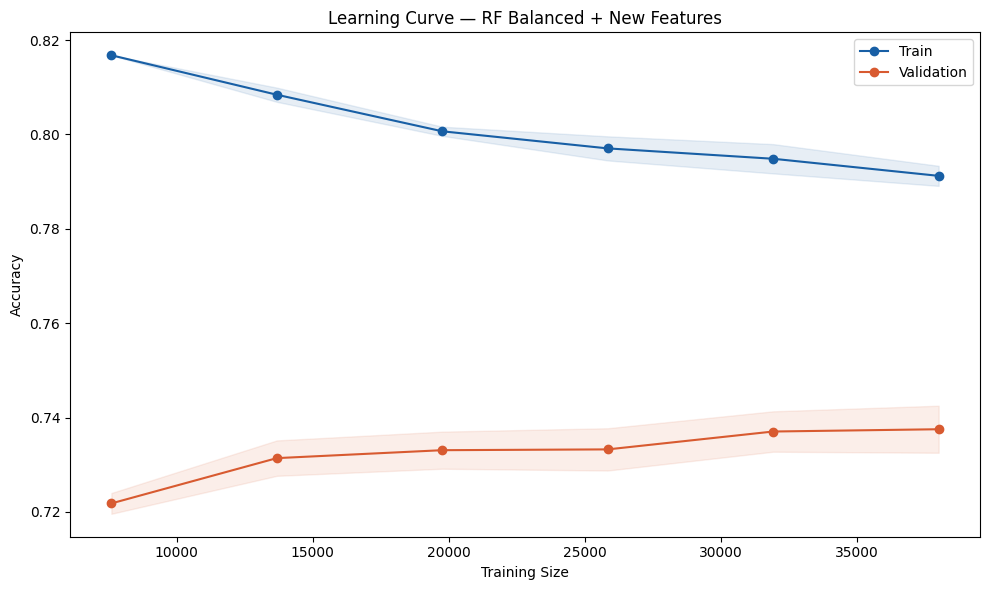


Final gap: 0.7912 (train) - 0.7375 (val) = 0.0537


In [72]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipe_balanced, X_train, y_train,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#185FA5', label='Train')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#185FA5')
ax.plot(train_sizes, val_mean, 'o-', color='#D85A30', label='Validation')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='#D85A30')

ax.set_xlabel('Training Size')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curve — RF Balanced + New Features')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal gap: {train_mean[-1]:.4f} (train) - {val_mean[-1]:.4f} (val) = {train_mean[-1] - val_mean[-1]:.4f}")

In [73]:
joblib.dump(pipe_balanced, 'rf_balanced_new_features_pipeline.pkl')
print(f"Saved: rf_balanced_new_features_pipeline.pkl")
print(f"Val Accuracy: {accuracy_score(y_val, y_pred_bal):.4f}")

Saved: rf_balanced_new_features_pipeline.pkl
Val Accuracy: 0.7397


In [ ]:
pipe_gb = Pipeline([
    ('preprocess', clone(tree_pre)),
    ('model', GradientBoostingClassifier(random_state=42))
])

param_dist = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [3, 5, 7, 9],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
}

search_gb = RandomizedSearchCV(
    pipe_gb, param_dist,
    n_iter=20, cv=5,
    scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=1
)

search_gb.fit(X_train, y_train)

print(f"Best CV Score: {search_gb.best_score_:.4f}")
print(f"Best Params: {search_gb.best_params_}")
print(f"Val Accuracy: {accuracy_score(y_val, search_gb.predict(X_val)):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV Score: 0.7939
Best Params: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 9, 'model__learning_rate': 0.05}
Val Accuracy: 0.7961


GB Val Accuracy: 0.7961
RF Val Accuracy: 0.7979

                         precision    recall  f1-score   support

             functional       0.79      0.90      0.84      6452
functional needs repair       0.53      0.27      0.36       863
         non functional       0.84      0.75      0.79      4565

               accuracy                           0.80     11880
              macro avg       0.72      0.64      0.66     11880
           weighted avg       0.79      0.80      0.79     11880



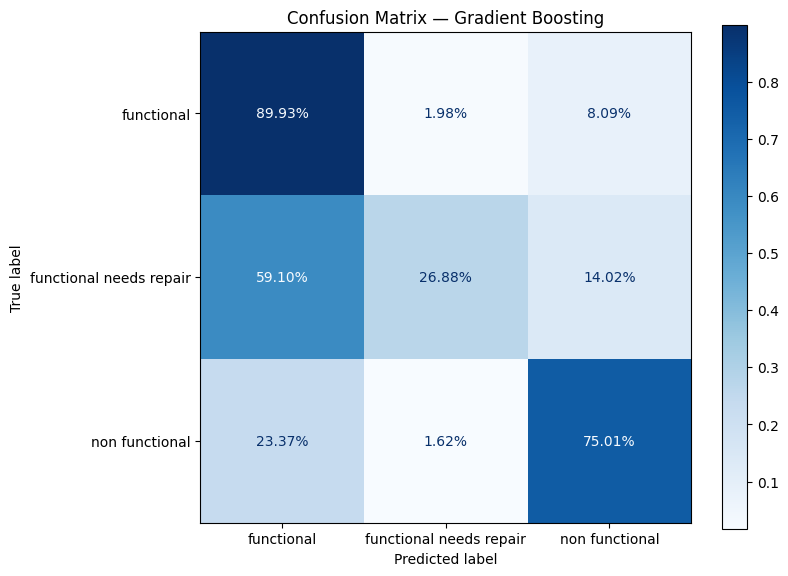

In [ ]:
y_pred_gb = search_gb.predict(X_val)
print(f"GB Val Accuracy: {accuracy_score(y_val, y_pred_gb):.4f}")
print(f"RF Val Accuracy: {accuracy_score(y_val, search.predict(X_val)):.4f}")

print(f"\n{classification_report(y_val, y_pred_gb)}")


fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_gb, ax=ax, cmap='Blues',
                                         normalize='true', values_format='.2%')
ax.set_title('Confusion Matrix — Gradient Boosting')
plt.tight_layout()
plt.show()